# **Check Class Imbalance**

### **Objective**
Confirm the class balance of the target (`Status`) on `y_train` and decide
whether — and how — to handle the imbalance before training models.

**1-Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,roc_auc_score, RocCurveDisplay, f1_score)

**2-Load y_train**

In [29]:
y_train = pd.read_csv("y_train.csv").squeeze()
print(y_train.shape)
y_train.head()


(35000,)


,Status
0,0
1,0
2,0
3,0
4,1


**3-Quantify the Imbalance**

In [30]:
counts = y_train.value_counts()
percentages = y_train.value_counts(normalize=True) * 100
print("Counts:\n", counts)
print("\nPercentages:\n", percentages)
imbalance_ratio = counts.max() / counts.min()
print(f"\nImbalance ratio (majority : minority) = {imbalance_ratio:.2f} : 1")


Counts:
 Status
0    26375
1     8625
Name: count, dtype: int64

Percentages:
 Status
0    75.357143
1    24.642857
Name: proportion, dtype: float64

Imbalance ratio (majority : minority) = 3.06 : 1


**4-Visualize the Class Balance**

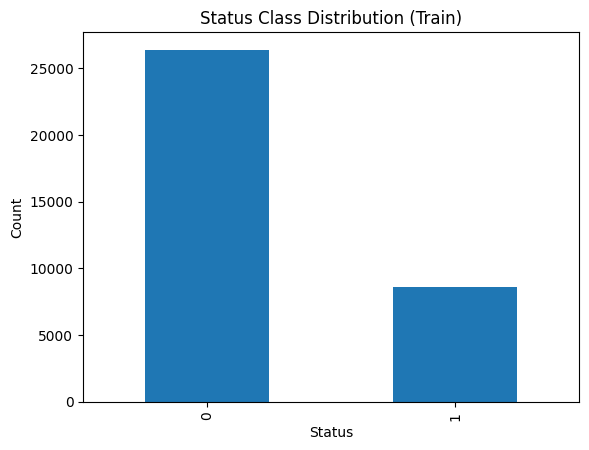

In [31]:
counts.plot(kind="bar")
plt.title("Status Class Distribution (Train)")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()


**5-Options for Handling Imbalance**

In [32]:
class_weights = compute_class_weight(class_weight="balanced",classes=np.unique(y_train),y=y_train)
classes = np.unique(y_train)
class_weight_dict = {}
for i in range(len(classes)):
    class_weight_dict[classes[i]] = class_weights[i]

print(class_weight_dict)

{np.int64(0): np.float64(0.6635071090047393), np.int64(1): np.float64(2.028985507246377)}


**7-(Optional) SMOTE — Only If Class Weights Aren't Enough**



In [33]:
# from imblearn.over_sampling import SMOTE
# X_train_processed = pd.read_csv("X_train_processed.csv")
# smote = SMOTE(random_state=42)
# X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed,y_train)
# print("Before SMOTE:")
# print(y_train.value_counts())
# print("\nAfter SMOTE:")
# print(y_train_balanced.value_counts())


**8-Save the Class Weights for the Modeling Step**

In [34]:
import json
weights = {str(key): value for key, value in class_weight_dict.items()}
with open("class_weights.json", "w") as file:
    json.dump(weights, file, indent=4)

# **Baseline Models**

### **Objective**
Train a few simple, standard models on `X_train_processed` / `y_train`,
evaluate them on `X_val_processed` / `y_val`, and get a first read on
performance before investing time in tuning.

**1-Load Processed Data**

In [36]:
X_train = pd.read_csv("X_train_processed.csv")
X_val   = pd.read_csv("X_val_processed.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_val   = pd.read_csv("y_val.csv").squeeze()
print("Train:", X_train.shape, "Val:", X_val.shape)


Train: (35000, 56) Val: (7500, 56)


**2-Baseline 1 — Logistic Regression**

In [37]:
log_reg = LogisticRegression(class_weight="balanced",max_iter=1000,random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_val)
y_proba_lr = log_reg.predict_proba(X_val)[:, 1]
print(classification_report(y_val, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_val, y_proba_lr))

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      5651
           1       0.66      0.64      0.65      1849

    accuracy                           0.83      7500
   macro avg       0.77      0.76      0.77      7500
weighted avg       0.83      0.83      0.83      7500

ROC-AUC: 0.8344387181600312


**3-Baseline 2 — Random Forest**



In [38]:
rf = RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=42,n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
y_proba_rf = rf.predict_proba(X_val)[:, 1]
print(classification_report(y_val, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_val, y_proba_rf))

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      5651
           1       0.91      0.52      0.66      1849

    accuracy                           0.87      7500
   macro avg       0.89      0.75      0.79      7500
weighted avg       0.87      0.87      0.86      7500

ROC-AUC: 0.8489360732852962


**4-Confusion Matrices**

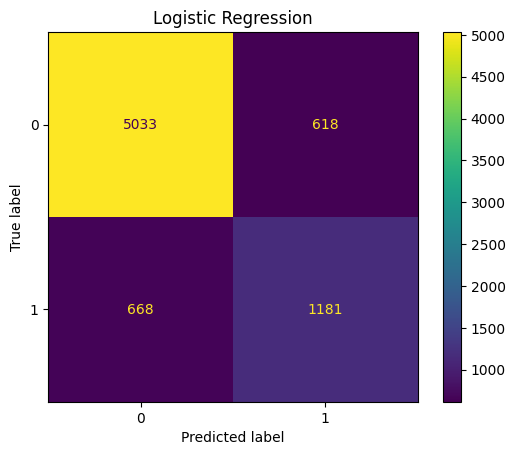

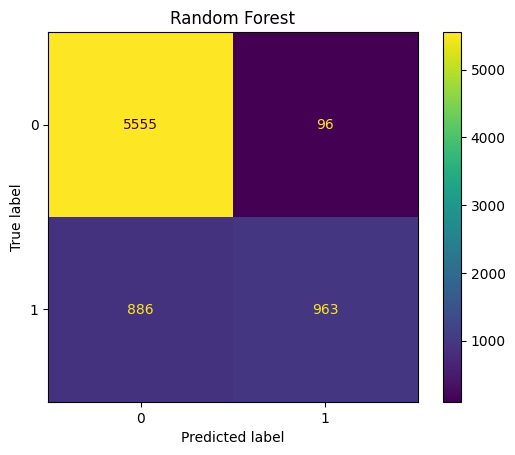

In [43]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_lr)
plt.title("Logistic Regression")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_rf)
plt.title("Random Forest")
plt.show()


**5-ROC Curves Side by Side**

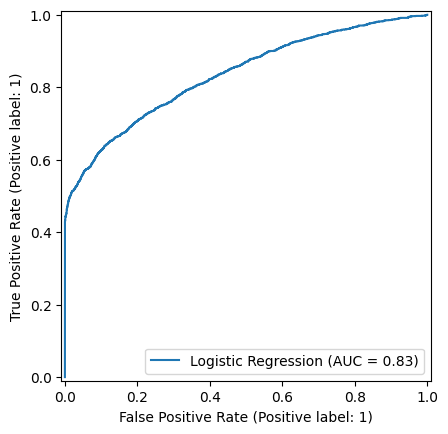

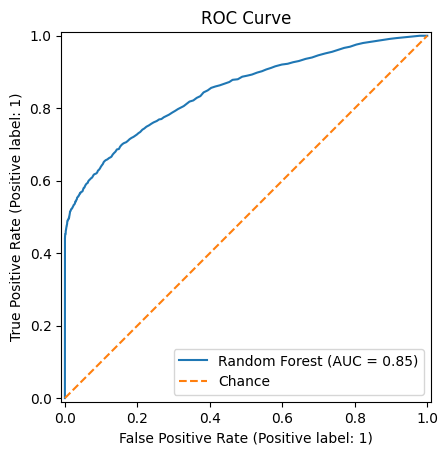

In [44]:
RocCurveDisplay.from_predictions(y_val,y_proba_lr,name="Logistic Regression")
RocCurveDisplay.from_predictions(y_val,y_proba_rf,name="Random Forest")
plt.plot([0, 1], [0, 1], "--", label="Chance")

plt.title("ROC Curve")
plt.legend()
plt.show()
